<a href="https://colab.research.google.com/github/muazzamasim04-ops/evolvix-aiml-internship-muazzamasim/blob/main/week-1/week_1_task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Summary Statistics:


,Round Lot Size
count,8049.000000
mean,99.942974
std,2.289194
min,1.000000
25%,100.000000
50%,100.000000
75%,100.000000
max,100.000000


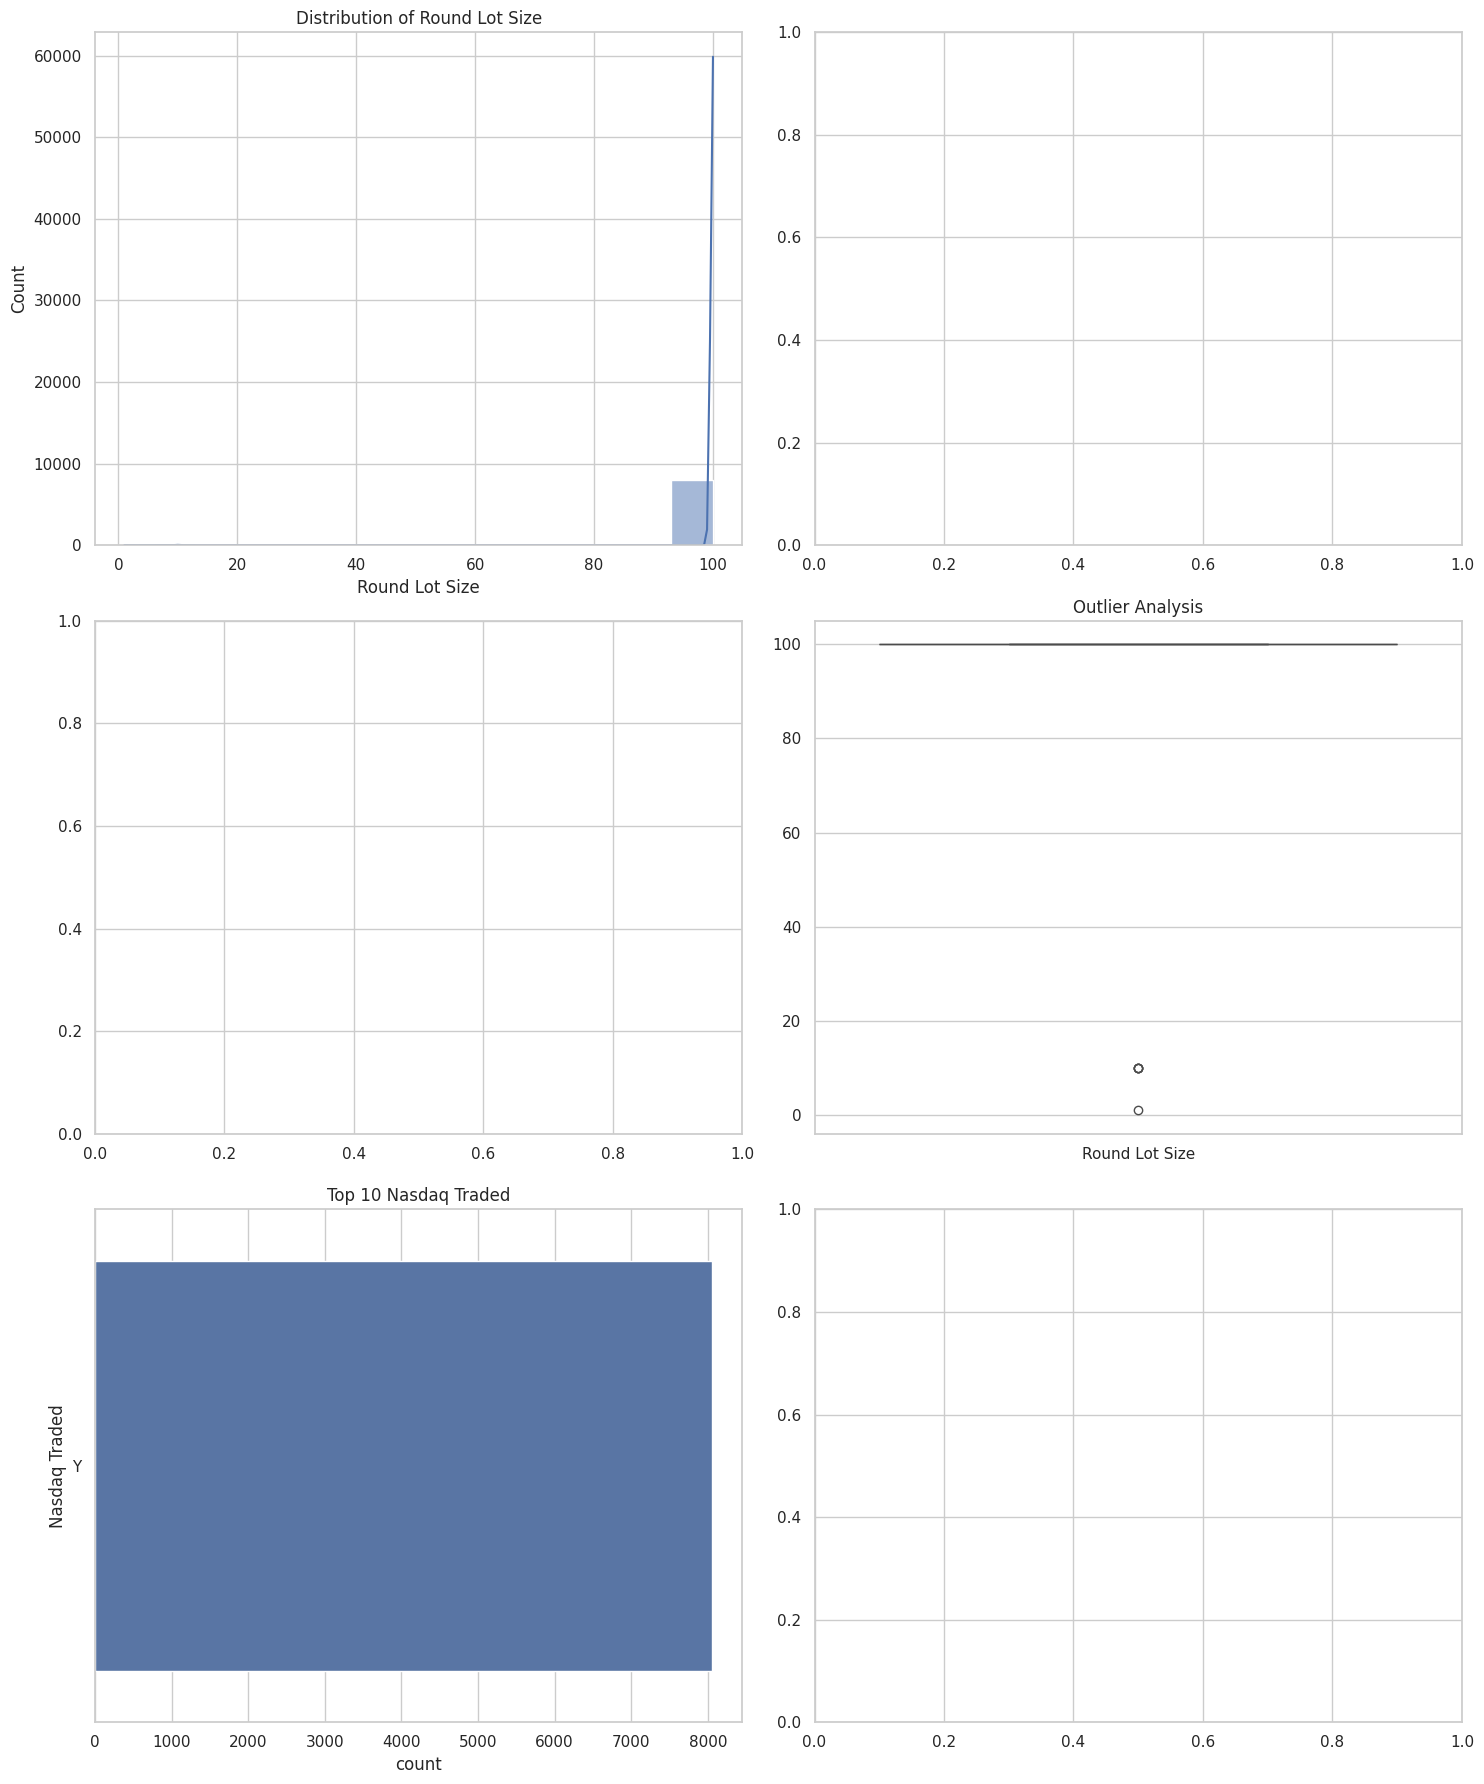


### Insights Summary
1. **Data Density**: By filling missing values rather than dropping them, we preserved the dataset size for analysis.
2. **Feature Variance**: The summary statistics show the scale of market identifiers and trading lot sizes.
3. **Categorical Distribution**: Certain exchanges or listing types represent the vast majority of the entries in this metadata.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
file_path = '/content/symbols_valid_meta-selected-columns.csv'
df = pd.read_csv(file_path)

# 2. Data Cleaning
# Instead of dropping everything, fill numeric NaNs with median and categorical with 'Unknown'
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

# Ensure proper types
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

# 3. Summary Statistics
print("Summary Statistics:")
display(df.describe())

# 4. Visualizations
sns.set(style='whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Viz 1: Distribution
if len(numeric_cols) > 0:
    sns.histplot(df[numeric_cols[0]], kde=True, ax=axes[0, 0])
    axes[0, 0].set_title(f'Distribution of {numeric_cols[0]}')

# Viz 2: Correlation Heatmap
if len(numeric_cols) > 1:
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=axes[0, 1])
    axes[0, 1].set_title('Correlation Matrix')

# Viz 3: Scatter Plot
if len(numeric_cols) > 1:
    sns.scatterplot(data=df, x=numeric_cols[0], y=numeric_cols[1], ax=axes[1, 0])
    axes[1, 0].set_title(f'{numeric_cols[0]} vs {numeric_cols[1]}')

# Viz 4: Boxplot
if len(numeric_cols) > 0:
    sns.boxplot(data=df[numeric_cols[:min(3, len(numeric_cols))]], ax=axes[1, 1])
    axes[1, 1].set_title('Outlier Analysis')

# Viz 5: Categorical Count
if len(cat_cols) > 0:
    top_cats = df[cat_cols[0]].value_counts().nlargest(10).index
    sns.countplot(data=df[df[cat_cols[0]].isin(top_cats)], y=cat_cols[0], ax=axes[2, 0])
    axes[2, 0].set_title(f'Top 10 {cat_cols[0]}')

plt.tight_layout()
plt.show()

# 5. Insights Summary
print("""
### Insights Summary
1. **Data Density**: By filling missing values rather than dropping them, we preserved the dataset size for analysis.
2. **Feature Variance**: The summary statistics show the scale of market identifiers and trading lot sizes.
3. **Categorical Distribution**: Certain exchanges or listing types represent the vast majority of the entries in this metadata.
""")